In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# DO SIMULATIONS

In [1]:
fixed_source = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,

        :sigma => Float64, #Gaussian width. 
        :R_source => Float64
    ),

    agentODE = quote  

        r = sqrt((x)^2 + (y)^2)
        ll = sqrt(DMedium / delta)

        # evitar singularidad en r=0
        r_eff = max(r, 1e-3)

        mm = 1.0 * besselk(0, r_eff / ll)

        M = mm

        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote

        v_run = v
        v_tumble = 0.25 

        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)                  
        end


        if active 
            λrt = ωFrec*exp(-G) 

            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
            if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                active = false
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
            else     #Si rate baixa 
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
            end

        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            else
                active = false
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            end
        end
    end,
    
    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)
)

UndefVarError: UndefVarError: `CBMIntegrators` not defined

In [3]:
ns = [0.25, 0.5, 0.75, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
steps = 60000
vel = [5.0, 10.0, 20.0, 100.0]


for n in ns
    for (idx, v) in enumerate(vel)
        println("Running n=$n")

        com = Community(
            fixed_source,
            N=1000,
            dt=0.01,
            simBox = [-100.0 100.0; -100.0 100.0],
            NMedium = [100, 100]
        )   

        m = 1/100
        g = 1/10000
        d = 1

        com.Dr_run = 0.062

        com.v = v 

        com.ωFrec = 1.3
        com.Ki = 0.0182
        com.Ka = 3.0
        com.Nrec = 6.0
        com.ε0   = 6.0
        com.ε1   = -1.0
        com.ε2   = 80
        com.ε3   = 80

        com.τm = 1  

        com.α   = 6.0

        com.K = 2.0 

        com.Ky = 100.0
        com.Kz = 10.0
        com.Z = 5.0
        com.Yy = 0.1

        com.m = 1.        
        com.d = 1.        
        com.l = 3;

        Dc = 10 
        delta = 0.01

        d = delta/((v/10)^2)

        #Canviar lambda

        com.DMedium = Dc / n
        com.delta = d * n

        com.x = 2.5*sqrt(com.DMedium/com.delta)
        com.y = 2.5*sqrt(com.DMedium/com.delta)
        com.theta = rand(Uniform(0,2π),com.N)

        com.methyl .= 0.0
        com.Yp .= com.K


        loadToPlatform!(com, preallocateAgents=1000)
        
        outfile = @sprintf("fsb_lambda_v%s_l%s.jld2", v, n)  ###CANVIARRR NOOM

        jldopen(outfile, "w") do file

            meta = JLD2.Group(file, "meta")
            meta["DMedium"] = com.DMedium
            meta["delta"] = com.delta

            for step in 1:steps
                step!(com)

                stepname = @sprintf("step_%06d", step)
                g = JLD2.Group(file, stepname)

                # Agent-level arrays (length = N)
                g["x"] = copy(com.x)
                g["y"] = copy(com.y)
                g["theta"] = copy(com.theta)

    
            end
        end
    end
end

Running n=0.25
Running n=0.25
Running n=0.25
Running n=0.25
Running n=0.5
Running n=0.5
Running n=0.5
Running n=0.5
Running n=0.75
Running n=0.75
Running n=0.75
Running n=0.75
Running n=1.0
Running n=1.0
Running n=1.0
Running n=1.0
Running n=2.0
Running n=2.0
Running n=2.0
Running n=2.0
Running n=3.0
Running n=3.0
Running n=3.0
Running n=3.0
Running n=4.0
Running n=4.0
Running n=4.0
Running n=4.0
Running n=5.0
Running n=5.0
Running n=5.0
Running n=5.0
Running n=6.0
Running n=6.0
Running n=6.0
Running n=6.0
Running n=7.0
Running n=7.0
Running n=7.0
Running n=7.0
Running n=8.0
Running n=8.0
Running n=8.0
Running n=8.0
Running n=9.0
Running n=9.0
Running n=9.0
Running n=9.0
Running n=10.0
Running n=10.0
Running n=10.0
Running n=10.0


# COMPARE VELOCITIES

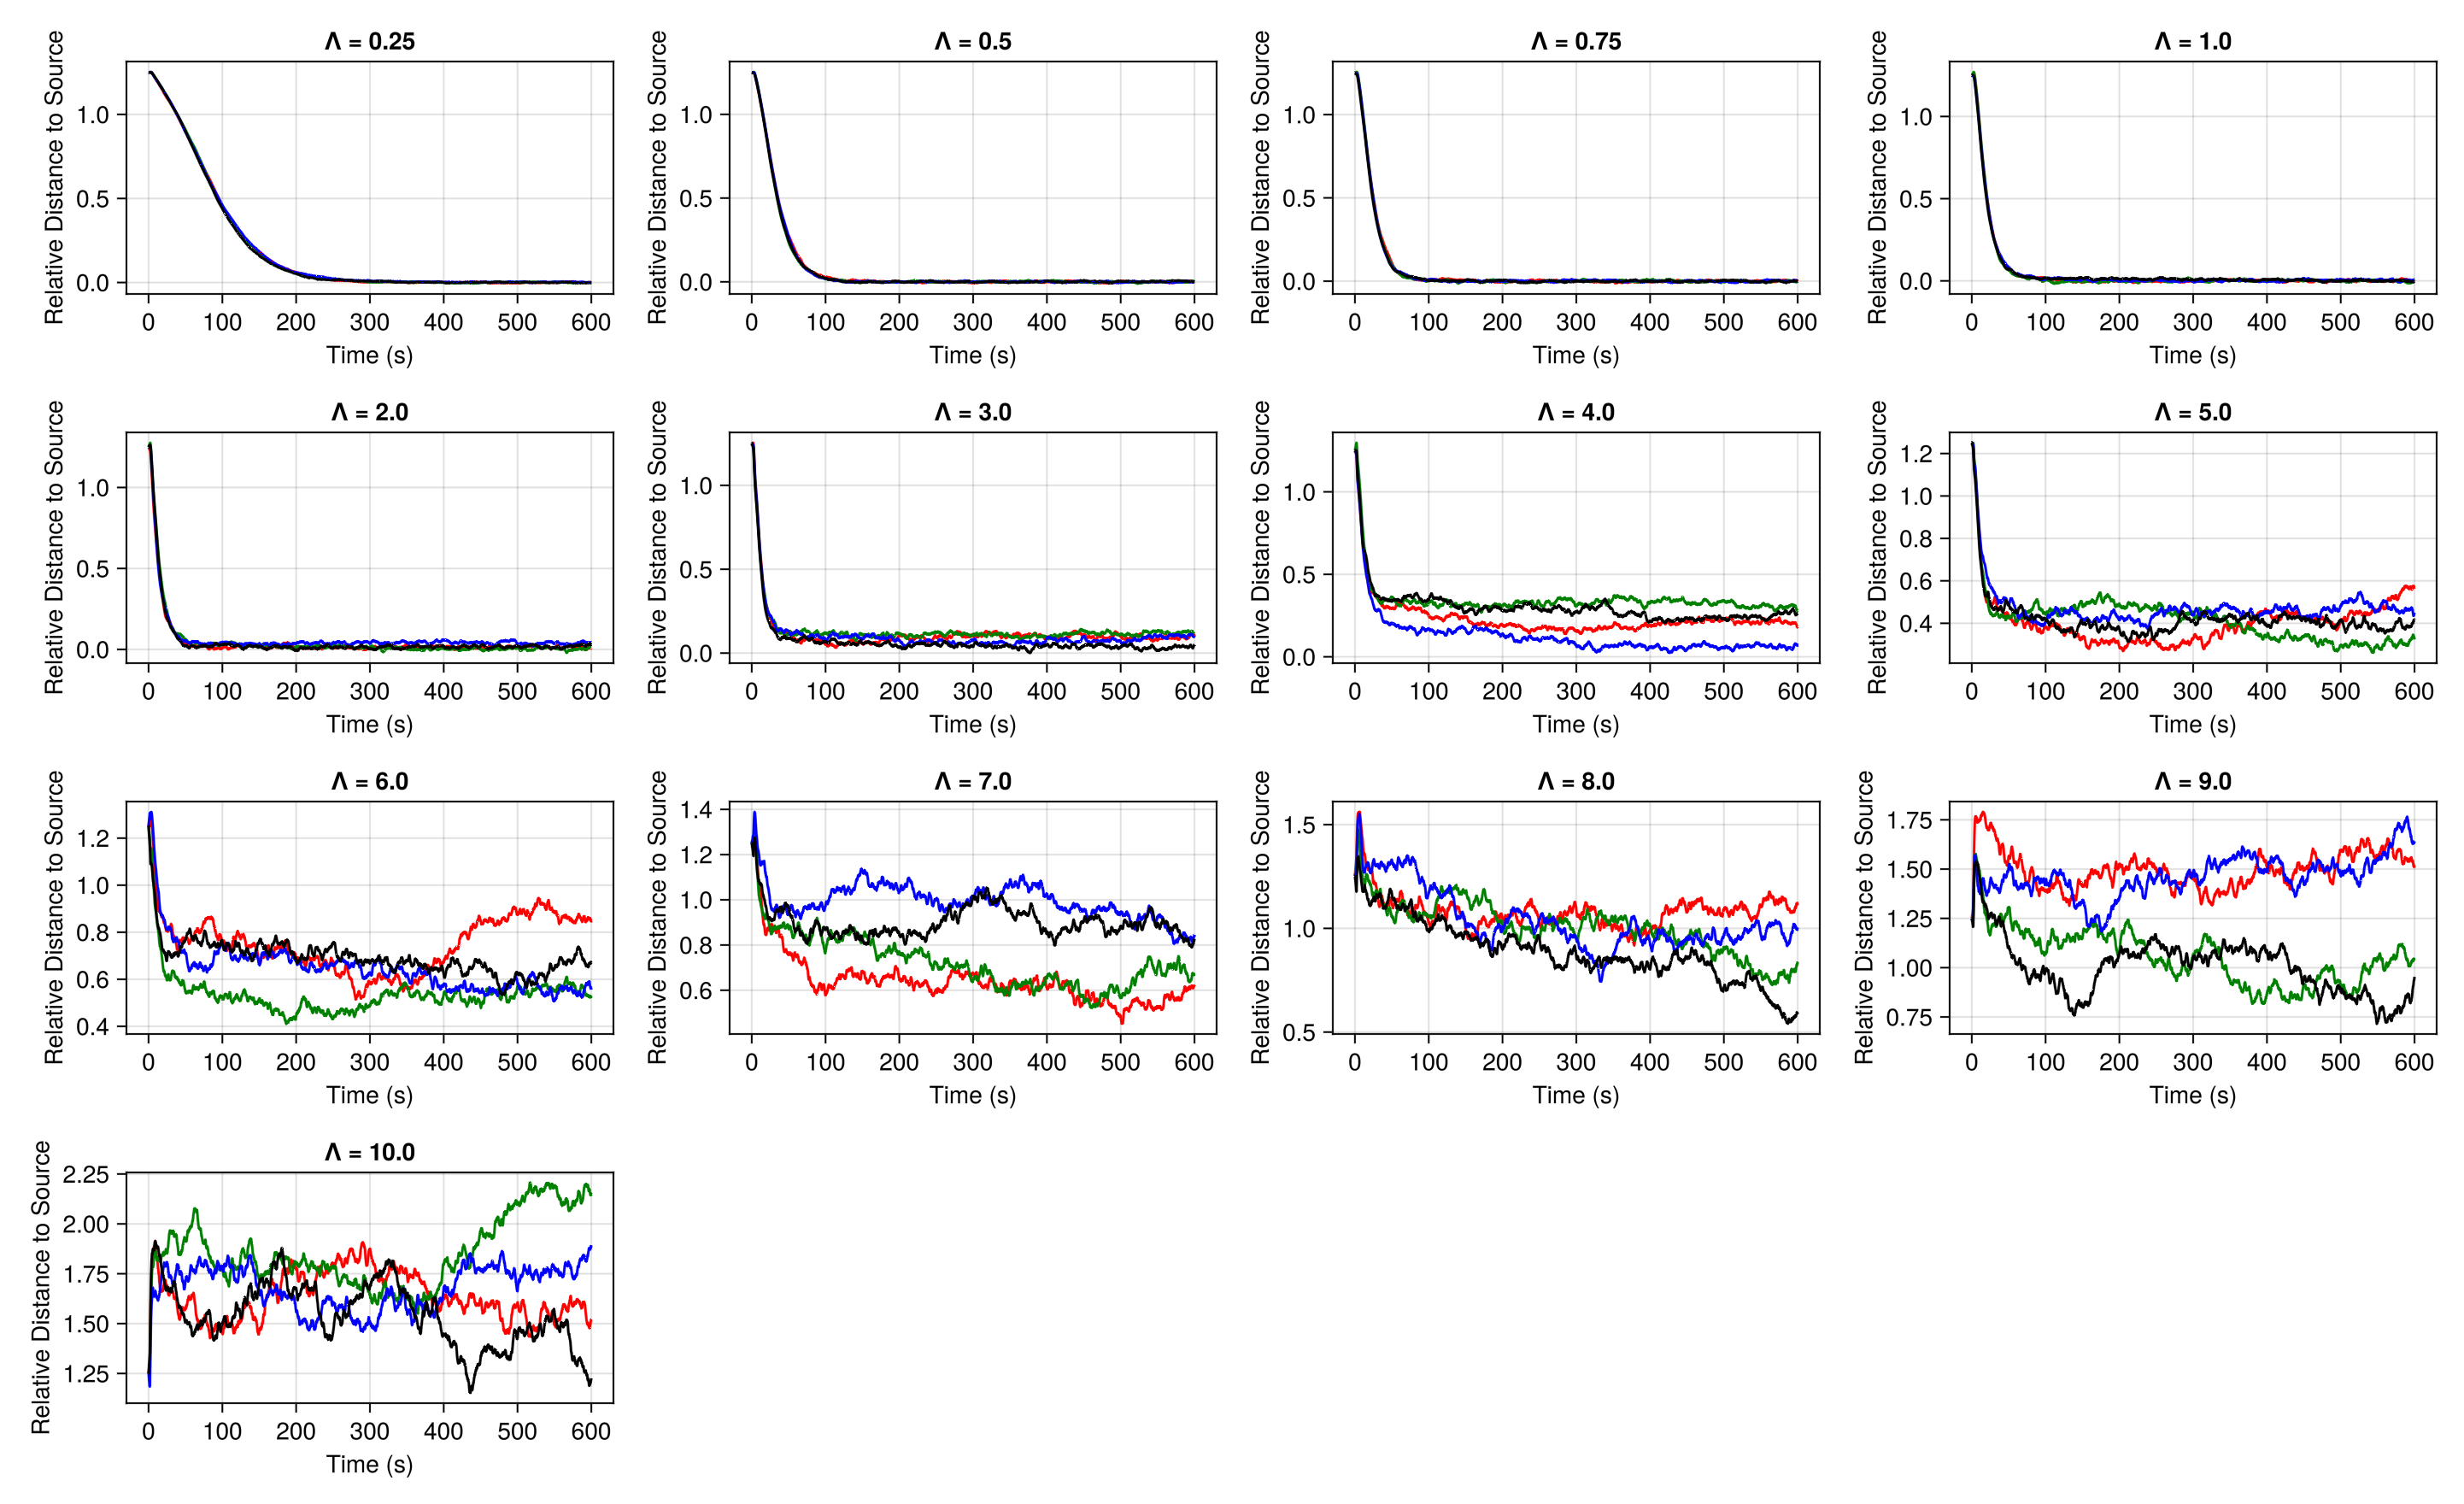

GLMakie.Screen(...)

In [2]:
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000

# Define the velocities to test
# velocities = [2.0]
velocities = [5.0, 10.0, 20.0, 100.0]
colors = [:red, :green, :blue, :black]

# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig1 = Figure(size=(900 * cols, 600 * rows))
fig2 = Figure(size=(900 * cols, 600 * rows))

# Loop through each lambda value FIRST (creates the grid)
for (idx, lambda) in enumerate(lambdas)
    # Determine grid position
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax = Axis(fig1[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")
    ax_y = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")    
    # Loop through each velocity to plot on the SAME axis
    for (v_idx, v) in enumerate(velocities)
        color = colors[v_idx]
        try
            # Filename format: fsb_{v}_lambda_{lambda}.jld2
            filename = @sprintf("fsb_lambda_v%s_l%s.jld2", v, lambda)
        
            jldopen(filename, "r") do file 
                raw_dist_x = Float64[]
                raw_dist_y = Float64[]

                meta_data = file["meta"]
                Dc = meta_data["DMedium"]
                delta = meta_data["delta"]
                l = sqrt(Dc/delta)
                
                for step in 1:steps
                    g = file[@sprintf("step_%06d", step)]

                    other_x = g["x"]
                    other_y = g["y"]

                    dx = other_x .- 0
                    dy = other_y .- 0
                    
                    dists_x = dx ./ l
                    dists_y = dy ./ l

                    push!(raw_dist_x, mean(dists_x))
                    push!(raw_dist_y, mean(dists_y))
            
                end
                
                # Plot the normalized line
                lines!(ax, (1:steps)*0.01, raw_dist_x, color = color, label="$v μm/s")
                lines!(ax_y, (1:steps)*0.01, raw_dist_y, color = color, label="$v μm/s")
    
            end
            if idx == 1 & v_idx == 4
                leg = Legend(fig1[:,5], ax, "Bacteria velocity")
                leg = Legend(fig2[:,5], ax, "Bacteria velocity")
            end

        catch e
            @warn "Could not load file for lambda $lambda, v=$v: $e"
        end
        
    end
end

display(fig1)

In [3]:
save("Plots/Fixed_source_model/Redo/v_comparison_ABM_x.png", fig1)
save("Plots/Fixed_source_model/Redo/v_comparison_ABM_y.png", fig2)

# Separate populations

## Visualize individual tracks

In [13]:
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]
n_files = length(lambdas)
steps = 60000

for (idx_v, v) in enumerate(vel)
    rows = 4
    cols = 4
    fig2 = Figure(size=(900 * cols, 600 * rows))

    for (idx, lambda) in enumerate(lambdas)
    
        filename = @sprintf("fsb_lambda_v%s_l%s.jld2", v, lambda)
        
        row = ceil(Int, idx / cols)
        col = (idx - 1) % cols + 1
        
        ax = Axis(fig2[row, col], 
                xlabel="Time (s)", 
                ylabel="Distance to source (X)",
                title="Λ = $lambda")

        jldopen(filename, "r") do file 
            for agent in 1:100
                mean_dist_x = Float64[] 
                for step in 1:10:steps
        
                    g = file[@sprintf("step_%06d", step)]

                    other_x = g["x"][agent]
                    dists_x = other_x .- 0

                    push!(mean_dist_x, mean(dists_x))
    
                end

                # Plotting X data
                lines!(ax, (1:10:steps)*0.01, mean_dist_x, label="Mean X")
            end
        end
    end
    save("Plots/Fixed_source_model/Redo/Trajectories_v$v.png", fig2)
end

## Check valid agents

In [4]:
function check_agent(file, step, agent_idx, threshold)

    data = file[@sprintf("step_%06d", step)]
    
    x = data["x"][agent_idx]
    y = data["y"][agent_idx]
    
    return (x <= threshold) && (y <= threshold) && (x >= -threshold) && (y >= -threshold)
end

check_agent (generic function with 1 method)

In [8]:
df_times = CSV.read("Files_threshold_time.csv", DataFrame)
df_times.lambda = parse.(Float64, replace.(df_times.lambda, "," => "."))

52-element Vector{Float64}:
  0.25
  0.5
  0.75
  1.0
  2.0
  3.0
  4.0
  5.0
  6.0
  7.0
  ⋮
  2.0
  3.0
  4.0
  5.0
  6.0
  7.0
  8.0
  9.0
 10.0

In [5]:
dfs_redo = Dict{Tuple{Float64, Float64}, DataFrame}()

lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]
vel_1 = [5, 10, 20, 100]
N_agents = 1000
end_step = 60000

for (v_idx, v) in enumerate(vel)
    for (l_idx, lambda) in enumerate(lambdas)

        filename = @sprintf("fsb_lambda_v%s_l%s.jld2", v, lambda)
        println("Processing $filename")

        # # lookup metadata
        filter_1 = df_times[df_times.v .== vel_1[v_idx], :]
        row = filter_1[filter_1.lambda .== lambda, :]

        if nrow(row) == 0
            println("  ⚠️ Skipping (not found in df_times)")
            continue
        end

        start_step = row.eq_time[1]*10
        threshold_distance = row.threshold[1]

        # -----------------------------
        # STEP 1: find valid agents
        # -----------------------------
        valid_agents = Int[]

        jldopen(filename, "r") do file
            for agent_idx in 1:N_agents
                is_valid = true

                for step in start_step:5:end_step
                    if !check_agent(file, step, agent_idx, threshold_distance)
                        is_valid = false
                        break
                    end
                end

                if is_valid
                    push!(valid_agents, agent_idx)
                end
            end
        end

        println("  ✔ valid agents: $(length(valid_agents))")

        # -----------------------------
        # STEP 2: extract trajectories
        # -----------------------------
        steps_vec = Int[]
        agents_vec = Int[]
        x_vec = Float64[]
        y_vec = Float64[]
        
        jldopen(filename, "r") do file
            for agent in valid_agents
                for step in 1:10:end_step
                    g = file[@sprintf("step_%06d", step)]

                    push!(steps_vec, step)
                    push!(agents_vec, agent)
                    push!(x_vec, g["x"][agent])
                    push!(y_vec, g["y"][agent])
                end
            end
        end

        df = DataFrame(
            step = steps_vec,
            agent = agents_vec,
            x = x_vec,
            y = y_vec
        )

        # store in dict
        dfs_redo[(v, lambda)] = df

    end
end

Processing fsb_lambda_v5.0_l0.25.jld2
  ✔ valid agents: 996
Processing fsb_lambda_v5.0_l0.5.jld2
  ✔ valid agents: 1000
Processing fsb_lambda_v5.0_l0.75.jld2
  ✔ valid agents: 999
Processing fsb_lambda_v5.0_l1.0.jld2
  ✔ valid agents: 998
Processing fsb_lambda_v5.0_l2.0.jld2
  ✔ valid agents: 994
Processing fsb_lambda_v5.0_l3.0.jld2
  ✔ valid agents: 982
Processing fsb_lambda_v5.0_l4.0.jld2
  ✔ valid agents: 948
Processing fsb_lambda_v5.0_l5.0.jld2
  ✔ valid agents: 917
Processing fsb_lambda_v5.0_l6.0.jld2
  ✔ valid agents: 876
Processing fsb_lambda_v5.0_l7.0.jld2
  ✔ valid agents: 844
Processing fsb_lambda_v5.0_l8.0.jld2
  ✔ valid agents: 782
Processing fsb_lambda_v5.0_l9.0.jld2
  ✔ valid agents: 747
Processing fsb_lambda_v5.0_l10.0.jld2
  ✔ valid agents: 704
Processing fsb_lambda_v10.0_l0.25.jld2
  ✔ valid agents: 993
Processing fsb_lambda_v10.0_l0.5.jld2
  ✔ valid agents: 1000
Processing fsb_lambda_v10.0_l0.75.jld2
  ✔ valid agents: 993
Processing fsb_lambda_v10.0_l1.0.jld2
  ✔ vali

In [6]:
@save "redo_dfs.jld2" dfs_redo

In [5]:
@load "redo_dfs.jld2" dfs_redo

1-element Vector{Symbol}:
 :dfs_redo

## Linear fit and histogram distribution

In [6]:
function linear_fit(x, y)
    """Simple linear regression: y = a + b*x"""
    n = length(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x .* y)
    sum_x2 = sum(x.^2)
    
    slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x^2)
    intercept = (sum_y - slope * sum_x) / n
    
    return slope, intercept
end

linear_fit (generic function with 1 method)

In [ ]:
function plot_descent_macro(dfs, df_times, vel, lambdas)

for v in vel

    fig = Figure(size=(1800, 1200))
    # fig_title = Label(fig[0, :], "Descent regions — v = $v")

    idx = 1

    for lambda in lambdas

        df = dfs[(t, λ)]
        filename = @sprintf("fsb_tm%s_lambda_%s.jld2", v, lambda)

        filtered = df_times[df_times.v .== v, :]
        row = filtered[filtered.lambda .== lambda, :]
        if nrow(row) == 0
            continue
        end

        eq_step = row.eq_time[1]*10

        descent = df[df.step .< eq_step, :]
        if nrow(descent) == 0
            continue
        end

        # group by step
        g = groupby(descent, :step)

        dist = combine(g, :x => (x -> abs(mean(x))) => :m)

        time = collect(1:nrow(dist)) 
        y = log.(dist.m)

        r = fld(idx-1, 4) + 1
        c = mod1(idx, 4)

        ax = Axis(fig[r, c],
            title = "λ = $λ",
            xlabel = "t",
            ylabel = "log|x|"
        )

        lines!(ax, time, y)

        idx += 1
    end

    save("descent_macro_tm$(t).png", fig)
end

end

In [82]:
times = CSV.read("times_cro.csv", DataFrame)

Row,v,lambda,time
,Int64,String7,Int64
1,5,"0,25",40
2,5,"0,5",15
3,5,"0,75",12
4,5,1,8
5,5,2,9
6,5,3,6
7,5,4,4
8,5,5,4
9,5,6,4


In [83]:
times.lambda = parse.(Float64, replace.(times.lambda, "," => "."))

52-element Vector{Float64}:
  0.25
  0.5
  0.75
  1.0
  2.0
  3.0
  4.0
  5.0
  6.0
  7.0
  ⋮
  2.0
  3.0
  4.0
  5.0
  6.0
  7.0
  8.0
  9.0
 10.0

In [116]:
metrics_redo = DataFrame(
    v = Float64[],
    lambda = Float64[],
    mu_x = Float64[],
    mu_y = Float64[],
    sigma_x = Float64[],
    sigma_y = Float64[],
    sigma = Float64[],
    k_x = Float64[],
    k_y = Float64[],
    k = Float64[],
    D = Float64[]
)

for ((v, lambda), df) in dfs_redo

    filter_1 = df_times[df_times.v .== v, :]
    row = filter_1[filter_1.lambda .== lambda, :]
    filter_1_t = times[times.v .== v, :]
    row_t = filter_1_t[filter_1_t.lambda .== lambda, :]


    if nrow(row) == 0
        continue
    end

    eq_step = row.eq_time[1]

    if ismissing(eq_step)
        println("Skipping $v, $lambda (missing params)")
        continue
    end

    # =========================
    # SPLIT DATA
    # =========================
    eq = df[df.step .>= eq_step, :]

    # =========================
    # EQUILIBRIUM STATS
    # =========================
    mu_x = mean(eq.x)
    mu_y = mean(eq.y)
    sigma_x = std(eq.x)
    sigma_y = std(eq.y)

    sigma = (sigma_x + sigma_y) / 2

    grouped_ag = groupby(eq, :agent)
    lags = (1:50:eq_step)

    correlations = zeros(length(grouped_ag), length(lags))
    correlations_y = zeros(length(grouped_ag), length(lags))

    for i in 1:length(grouped_ag)
        df_ag = grouped_ag[i]
        traj = df_ag.x
        traj_y = df_ag.y
        cor = autocor(traj, lags; demean = false)
        cor_y = autocor(traj_y, lags; demean = false)
        correlations[i, :] = cor
        correlations_y[i, :] = cor_y
    end

    correlations_mean = Float64[]
    correlations_mean_y = Float64[]

    for i in 1:length(lags)
        lag_mean = correlations[:, i]
        lag_mean_y = correlations_y[:, i]
        push!(correlations_mean, mean(lag_mean))
        push!(correlations_mean_y, mean(lag_mean_y))
    end

    fig = Figure(size=(900, 500))

    ax1 = Axis(fig[1, 1], title="Eq X", xlabel="Lags", ylabel = "Correlation")
    # ax2 = Axis(fig[1, 2], title="Eq Y", xlabel="y")

    # correlations
    # lines!(ax1, lags, correlations_mean)
    lines!(ax1, lags, (correlations_mean))
    # logx = log.(abs.(correlations_mean))
    # logy = log.(abs.(correlations_mean_y))
    # t = collect(1:length(correlations_mean))
    # position = round(Int, length(t) * 0.4)
    # fit_end = row_t.time[1]

    # slope_x, intercept_x = linear_fit(lags[1:fit_end], logx[1:fit_end])
    # slope_y, intercept_y = linear_fit(lags[1:fit_end], logy[1:fit_end])
    # k_x = -slope_x 
    # k_y = -slope_y
    # lines!(ax1, lags[1:fit_end], intercept_x .+ slope_x .* lags[1:fit_end], color=:red, linestyle=:dash)

    save("Plots/Fixed_source_model/Redo/cor_nolog_v$(v)_l$(lambda).png", fig)

    # k = (k_x + k_y) / 2
    # D = sigma^2 * k

    # =========================
    # DESCENT STATS
    # =========================
    # g = groupby(descent, :step)

    # dist = combine(g, :x => (x -> abs(mean(x))) => :m)

    # logx = log.(dist.m)
    # t = collect(1:length(dist.m))

    # slope_x, intercept_x = linear_fit(t[fit_start:fit_end], logx[fit_start:fit_end])
    # k_x = -slope_x *10


    # =========================
    # STORE METRICS
    # # =========================
    # push!(metrics_redo, (
    #     v,
    #     lambda,
    #     mu_x,
    #     mu_y,
    #     sigma_x,
    #     sigma_y,
    #     sigma,
    #     k_x,
    #     k_y,
    #     k,
    #     D
    # ))
end

In [96]:
@save "metrics_redo.jld2" metrics_redo

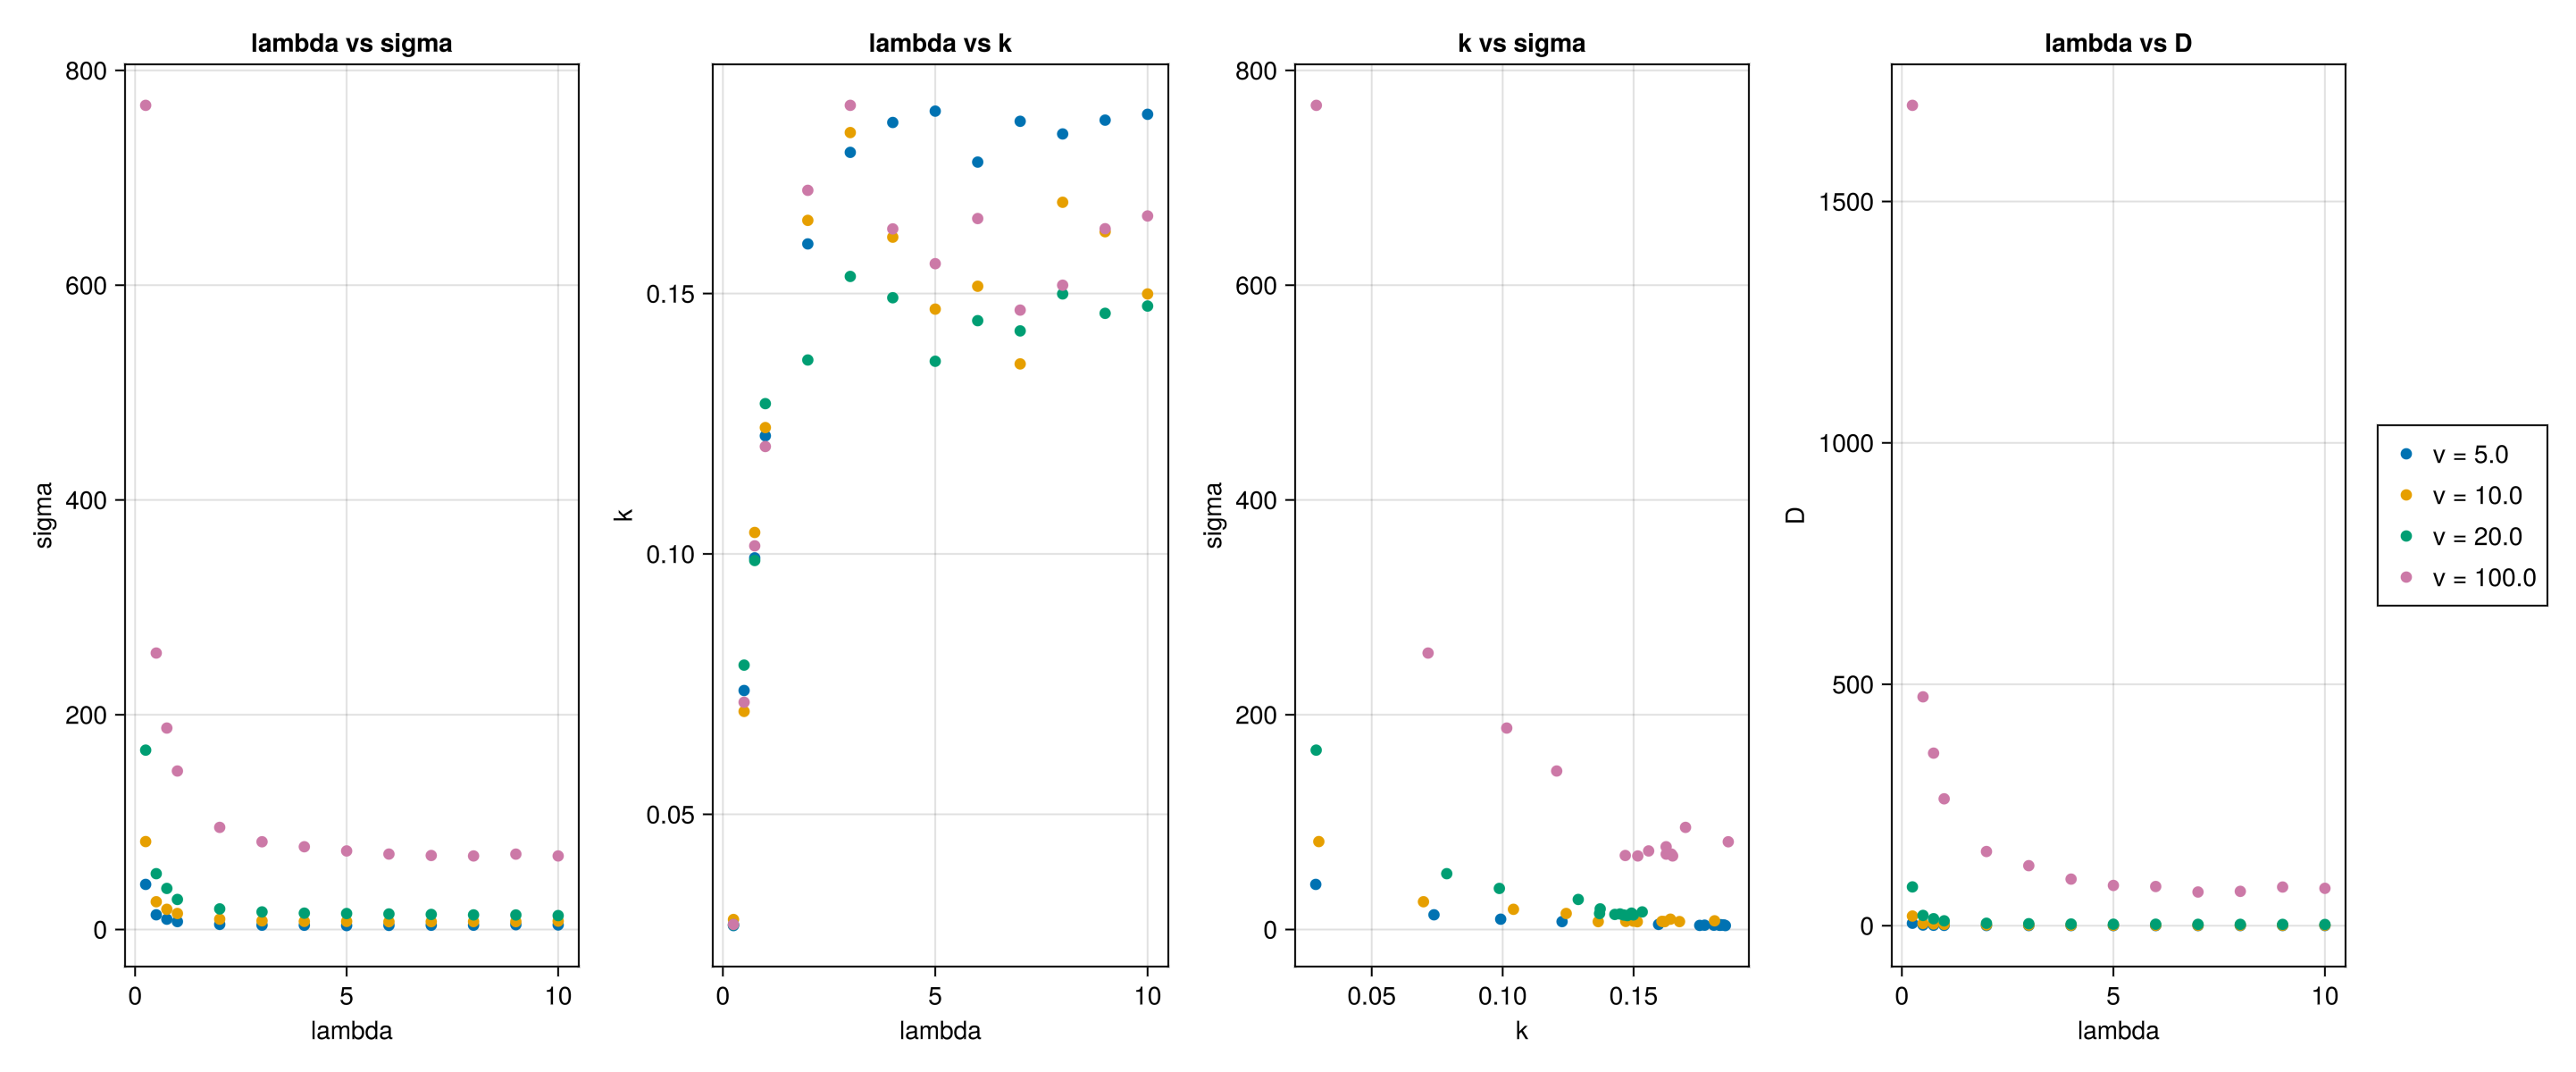

In [94]:
lambda = metrics_redo.lambda
sigma = metrics_redo.sigma
D = metrics_redo.D
k     = metrics_redo.k .*10
vvals = metrics_redo.v

fig = Figure(size = (2100, 600))

ax1 = Axis(fig[1, 1],
    xlabel = "lambda",
    ylabel = "sigma",
    title = "lambda vs sigma"
)

ax2 = Axis(fig[1, 2],
    xlabel = "lambda",
    ylabel = "k",
    title = "lambda vs k"
)

ax3 = Axis(fig[1, 3],
    xlabel = "k",
    ylabel = "sigma",
    title = "k vs sigma"
)

ax4 = Axis(fig[1,4],
    xlabel = "lambda",
    ylabel = "D",
    title = "lambda vs D"
)

# ax5 = Axis(fig[2,2],
#     xlabel = "sigma",
#     ylabel = "Attaractant field (l)",
#     title = "sigma vs l"
# )

# ax6 = Axis(fig[2,3],
#     xlabel = "D",
#     ylabel = "k",
#     title = "sigma vs l"
# )
# unique velocities
unique_v = [5.0, 10.0, 20.0, 100.0]

# choose a color palette
colors = Makie.wong_colors()

for (i, v) in enumerate(unique_v)

    idx = findall(==(v), vvals)

    c = colors[i]

    scatter!(ax1, lambda[idx], sigma[idx],
        color = c,
        label = "v = $v"
    )

    scatter!(ax2, lambda[idx], k[idx],
        color = c,
        label = "v = $v"
    )

    scatter!(ax3, k[idx], sigma[idx],
        color = c,
        label = "v = $v"
    )

    scatter!(ax4, lambda[idx], D[idx],
        color = c,
        label = "v = $v"
    )  

    # scatter!(ax5, sigma[idx], l[idx],
    #     color = c,
    #     label = "v = $v"
    # ) 

    # scatter!(ax6, D[idx], k[idx],
    #     color = c,
    #     label = "v = $v"
    # ) 
end

leg = Legend(fig[1,5], ax1)

fig

In [95]:
save("Plots/Fixed_source_model/Redo/metrics_3.png", fig)

# Keller + subpopulation

In [97]:
@load "mean_traj_keller_redo.jld2" mean_traj_mu_redo
@load "dc_delta.jld2" dc_delta

1-element Vector{Symbol}:
 :dc_delta

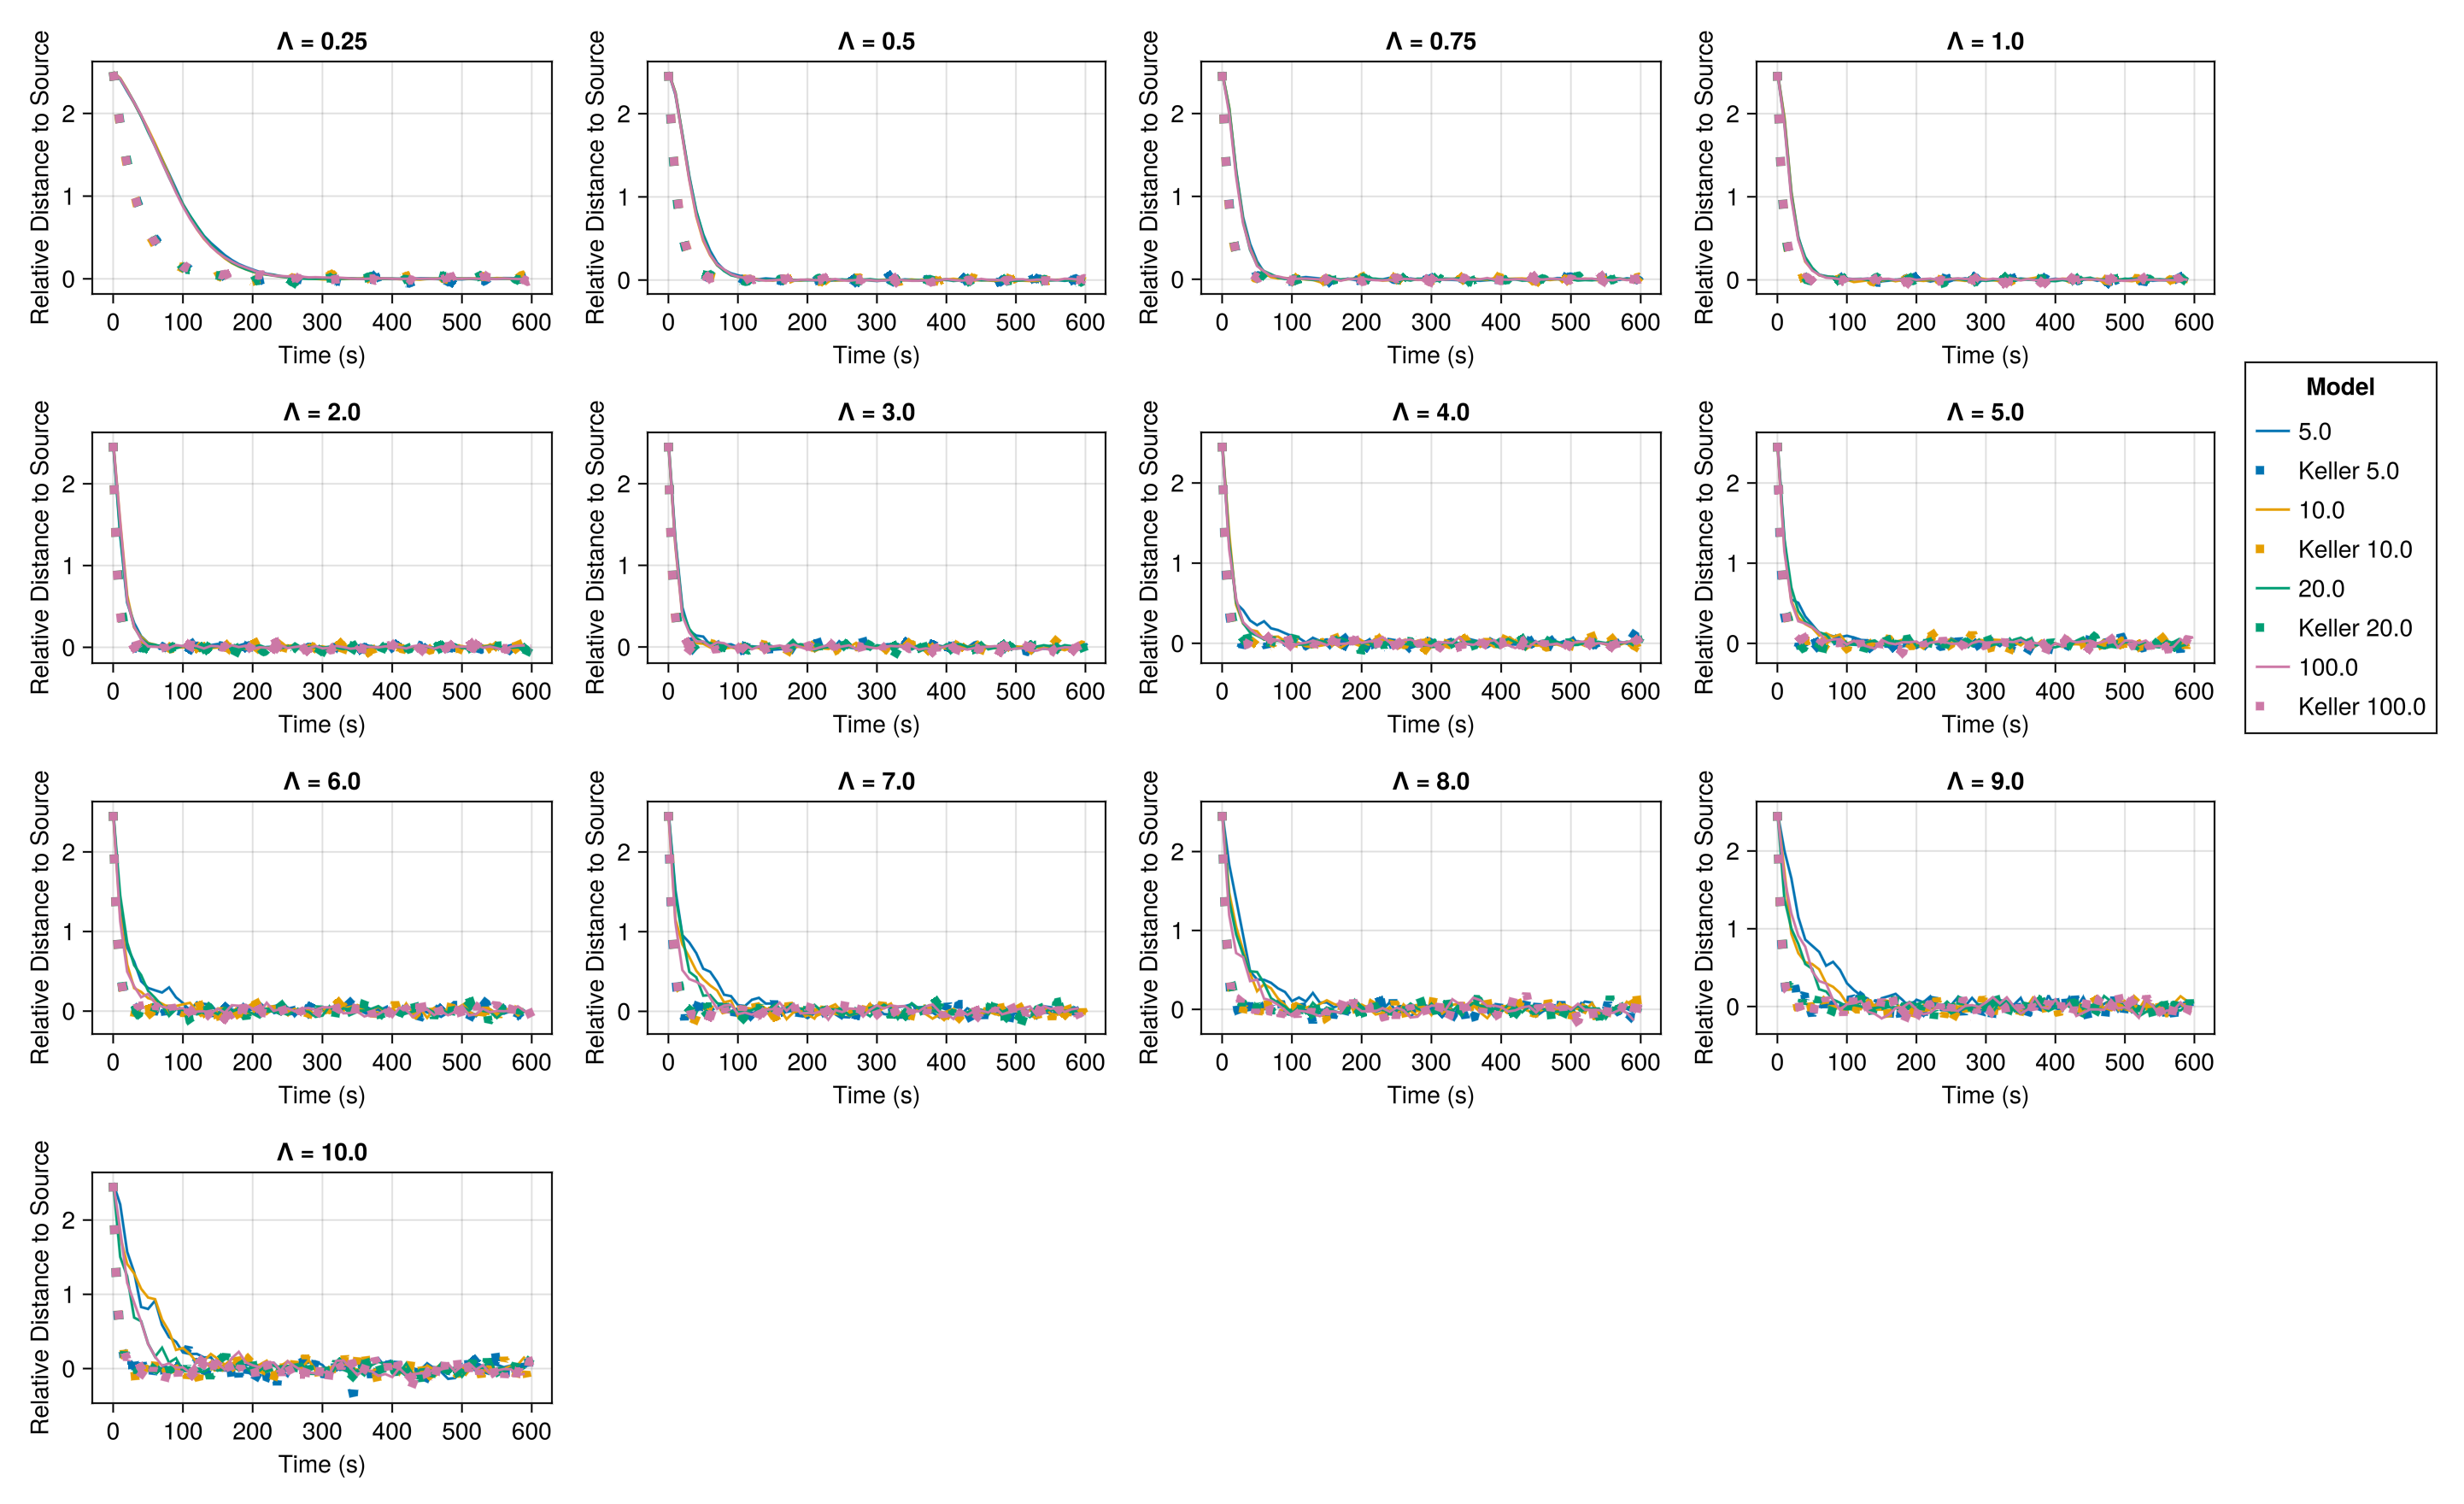

GLMakie.Screen(...)

In [106]:
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000

velocities = [5.0, 10.0, 20.0, 100.0]
# velocities = [5.0]
# velocities = [10.0]
# velocities = [20.0]
# velocities = [100.0]
# thresholds = [40, 75, 275, 850]
# thresholds = [40]
# thresholds = [75]
# thresholds = [275]
# thresholds = [850]

colors = [
    RGBf(0.0, 0.45, 0.70),   # blue
    RGBf(0.90, 0.62, 0.0),   # orange
    RGBf(0.0, 0.62, 0.45),   # green
    RGBf(0.80, 0.47, 0.65)   # magenta
]

# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig2 = Figure(size=(900 * cols, 600 * rows))


for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")

    
    for (v_idx, v) in enumerate(velocities)

        df = dfs_redo[(v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        for i in 1:100:length(grouped)
            data_1 = grouped[i]
            x = data_1.x ./l
            y = data_1.y ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        mask = (mean_traj_mu_redo.lambda .== lambda) .& (mean_traj_mu_redo.v .== v) 

        mean_keller = mean_traj_mu_redo.mean[mask]
        mean_keller_norm = mean_keller ./ l 
        flat_vec = vcat(mean_keller_norm...)
        idx_l = 1:100:length(flat_vec)
        lines!(ax_x, (1:100:length(grouped))*0.1, mean_x, color = color, label = "$v")
        lines!(ax_x, (1:100:length(flat_vec))*0.01, flat_vec[idx_l], color = color, linestyle = (:dot, :loose), linewidth = 5, label = "Keller $v")


        if idx == 13 & v_idx == 4
            fig2[2,5] = Legend(fig2, ax_x, "Model")
        end
    end
end

display(fig2)

In [107]:
save("Plots/Fixed_source_model/Redo/keller_trapped_ABM_x_new.png", fig2)

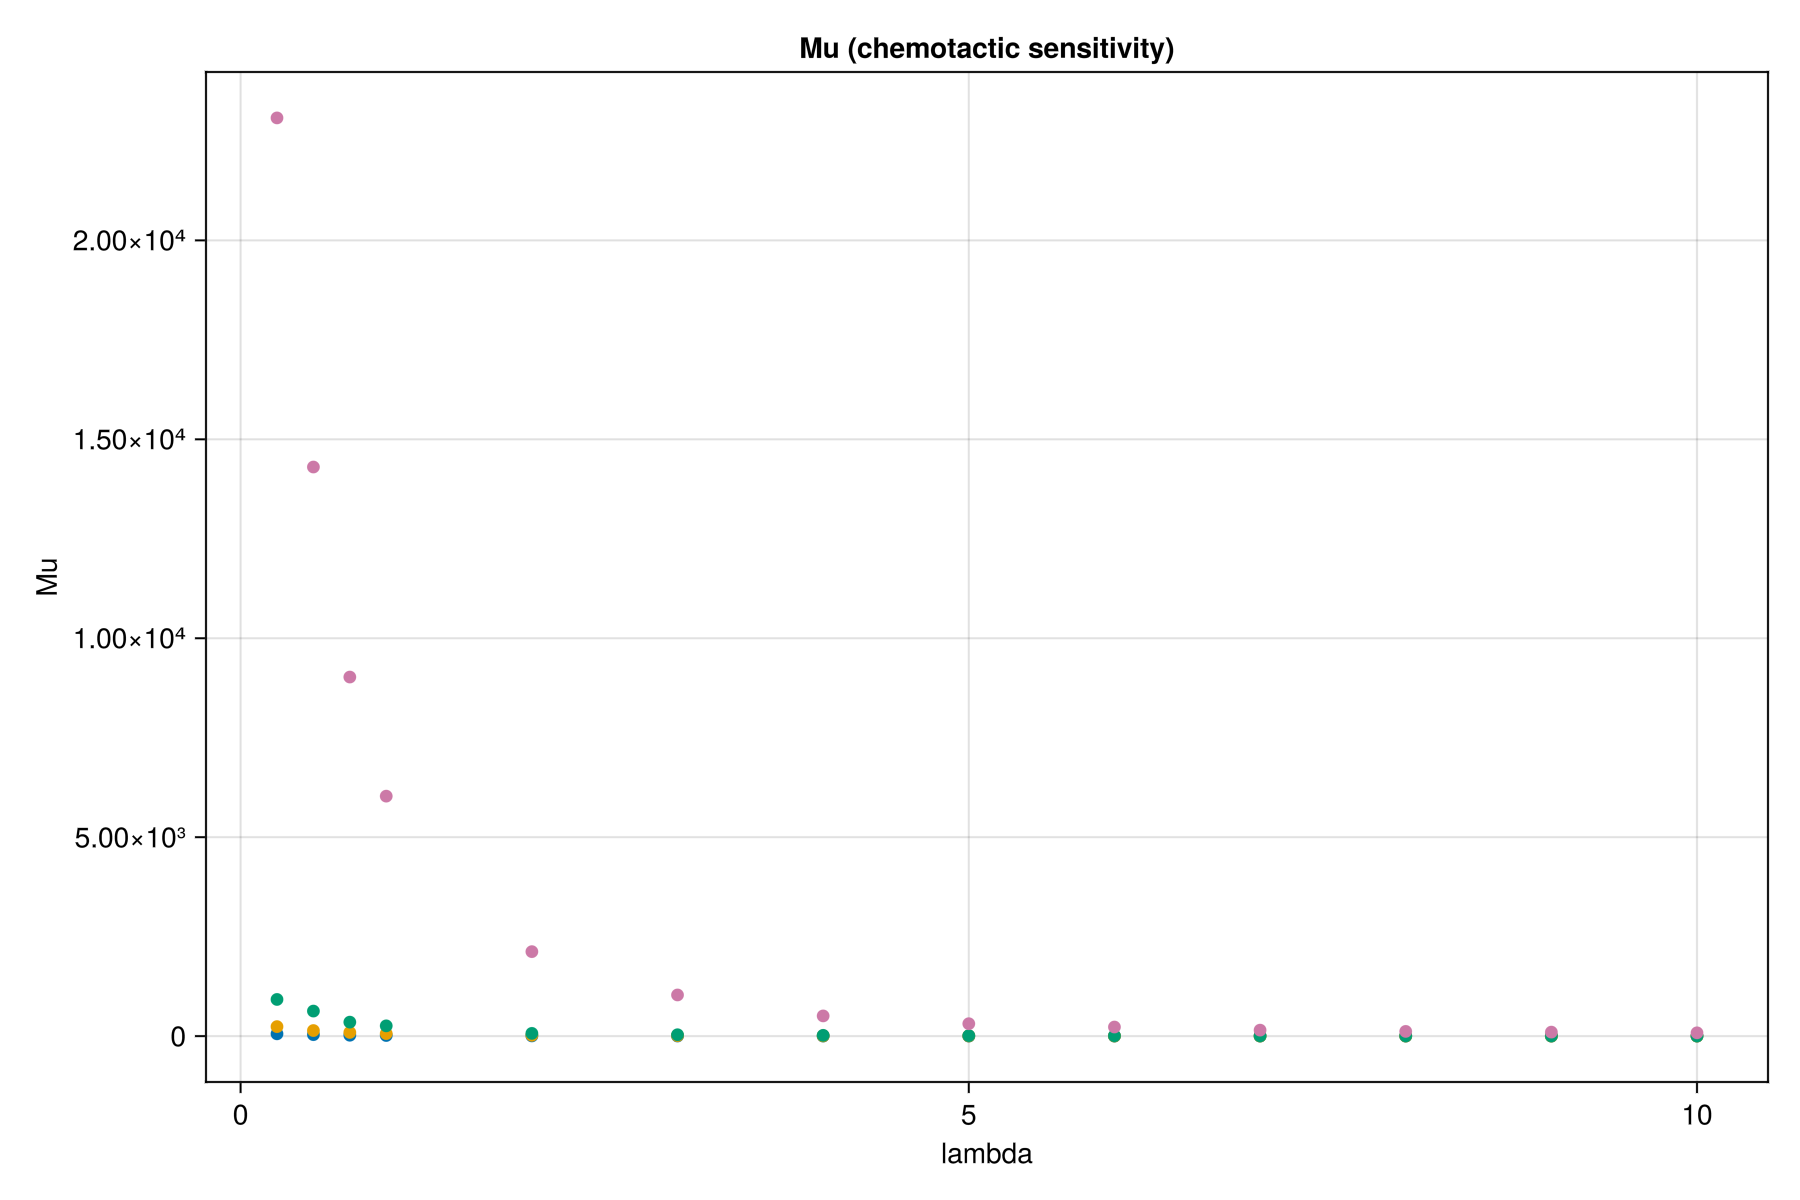

In [109]:
fig = Figure(size=(900, 600))
ax = Axis(fig[1,1], title = "Mu (chemotactic sensitivity)", xlabel = "lambda", ylabel = "Mu")
lambda = mean_traj_mu_redo.lambda
velocity = mean_traj_mu_redo.v
mu = mean_traj_mu_redo.mu
unique_v = [5.0, 10.0, 20.0, 100.0]
colors = Makie.wong_colors()

for (i, v) in enumerate(unique_v)
    idx = findall(==(v), velocity)
    c = colors[i]
    scatter!(ax, lambda[idx], mu[idx],
        color = c,
        label = "v = $v"
    )
end
fig

In [111]:
save("Plots/Fixed_source_model/Redo/mu_new.png", fig)

# OU + subpopulations

In [100]:
@load "mean_OU_redo.jld2" mean_traj_redo

1-element Vector{Symbol}:
 :mean_traj_redo

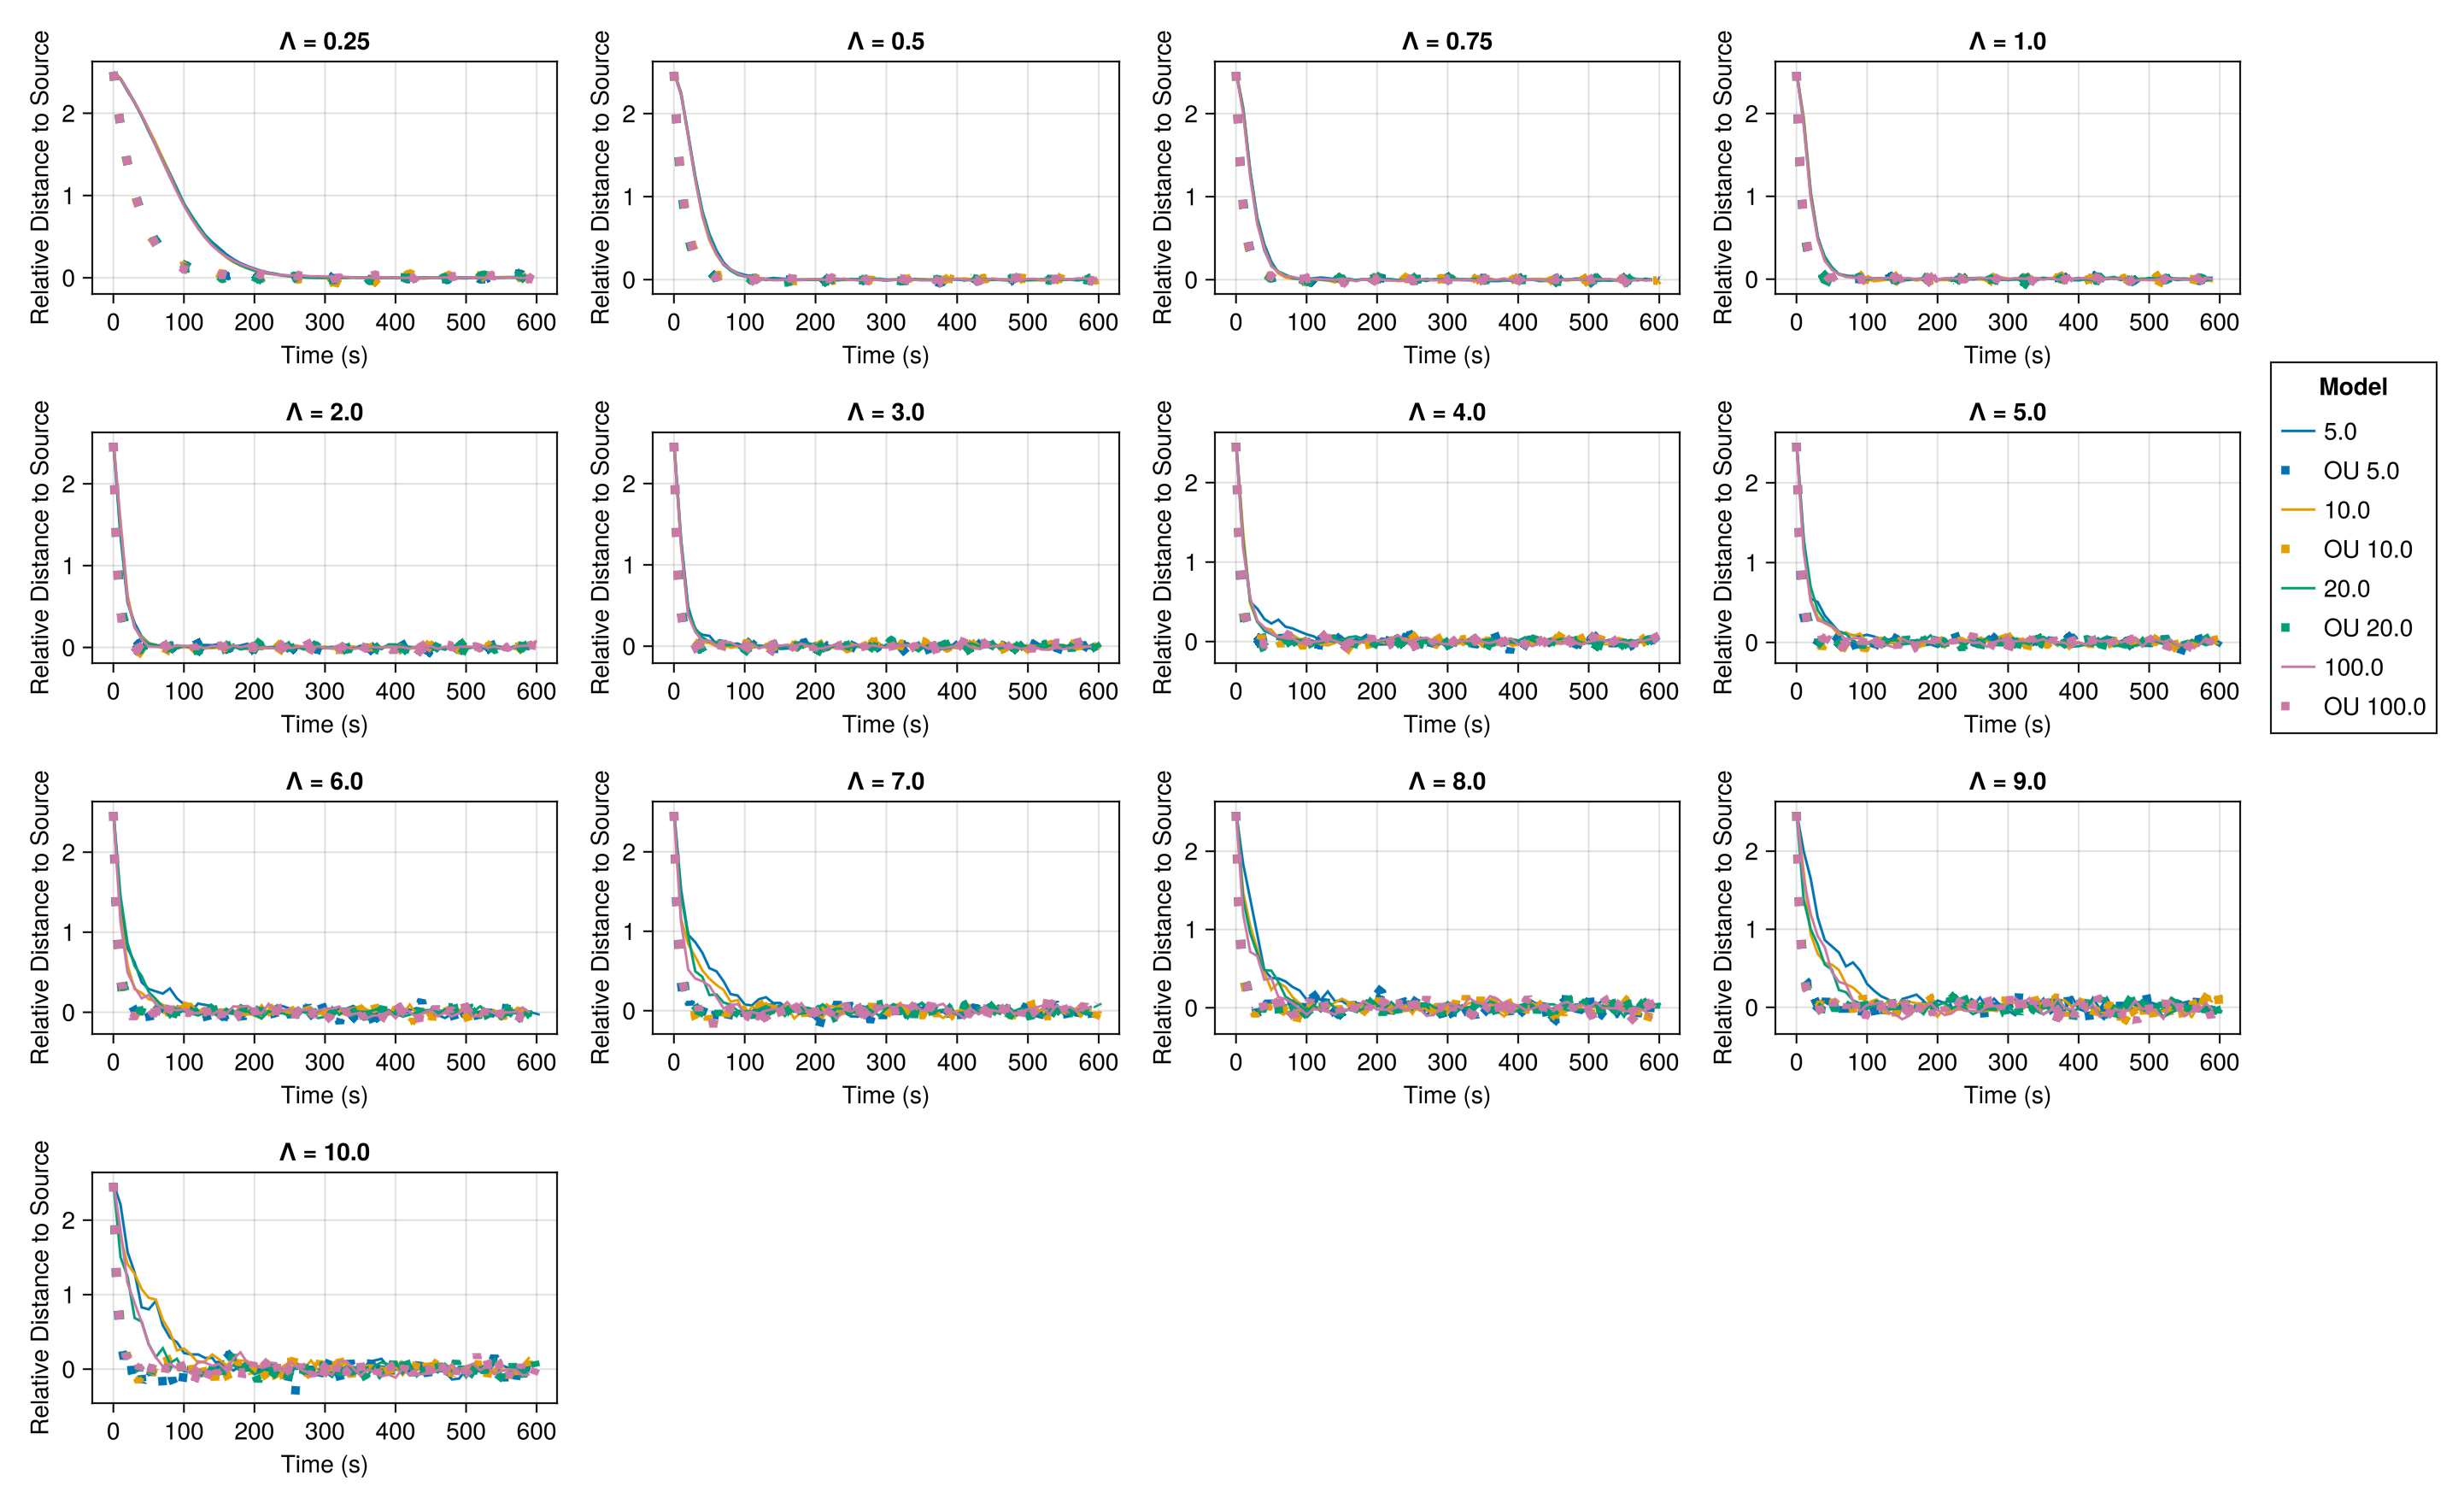

GLMakie.Screen(...)

In [103]:
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000

velocities = [5.0, 10.0, 20.0, 100.0]
# velocities = [5.0]
# velocities = [10.0]
# velocities = [20.0]
# velocities = [100.0]
# thresholds = [40, 75, 275, 850]
# thresholds = [40]
# thresholds = [75]
# thresholds = [275]
# thresholds = [850]

colors = [
    RGBf(0.0, 0.45, 0.70),   # blue
    RGBf(0.90, 0.62, 0.0),   # orange
    RGBf(0.0, 0.62, 0.45),   # green
    RGBf(0.80, 0.47, 0.65)   # magenta
]

# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig2 = Figure(size=(900 * cols, 600 * rows))


for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")

    
    for (v_idx, v) in enumerate(velocities)

        df = dfs_redo[(v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        for i in 1:100:length(grouped)
            data_1 = grouped[i]
            x = data_1.x ./l
            y = data_1.y ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        mask = (mean_traj_redo.lambda .== lambda) .& (mean_traj_redo.v .== v) 

        mean_OU = mean_traj_redo.mean[mask]
        mean_OU_norm = mean_OU ./ l 
        flat_vec = vcat(mean_OU_norm...)
        idx_l = 1:100:length(flat_vec)
        lines!(ax_x, (1:100:length(grouped))*0.1, mean_x, color = color, label = "$v")
        lines!(ax_x, (1:100:length(flat_vec))*0.01, flat_vec[idx_l], color = color, linestyle = (:dot, :loose), linewidth = 5, label = "OU $v")


        if idx == 13 & v_idx == 4
            fig2[2,5] = Legend(fig2, ax_x, "Model")
        end
    end
end

display(fig2)

In [105]:
save("Plots/Fixed_source_model/Redo/OU_trapped_ABM_x.png", fig2)

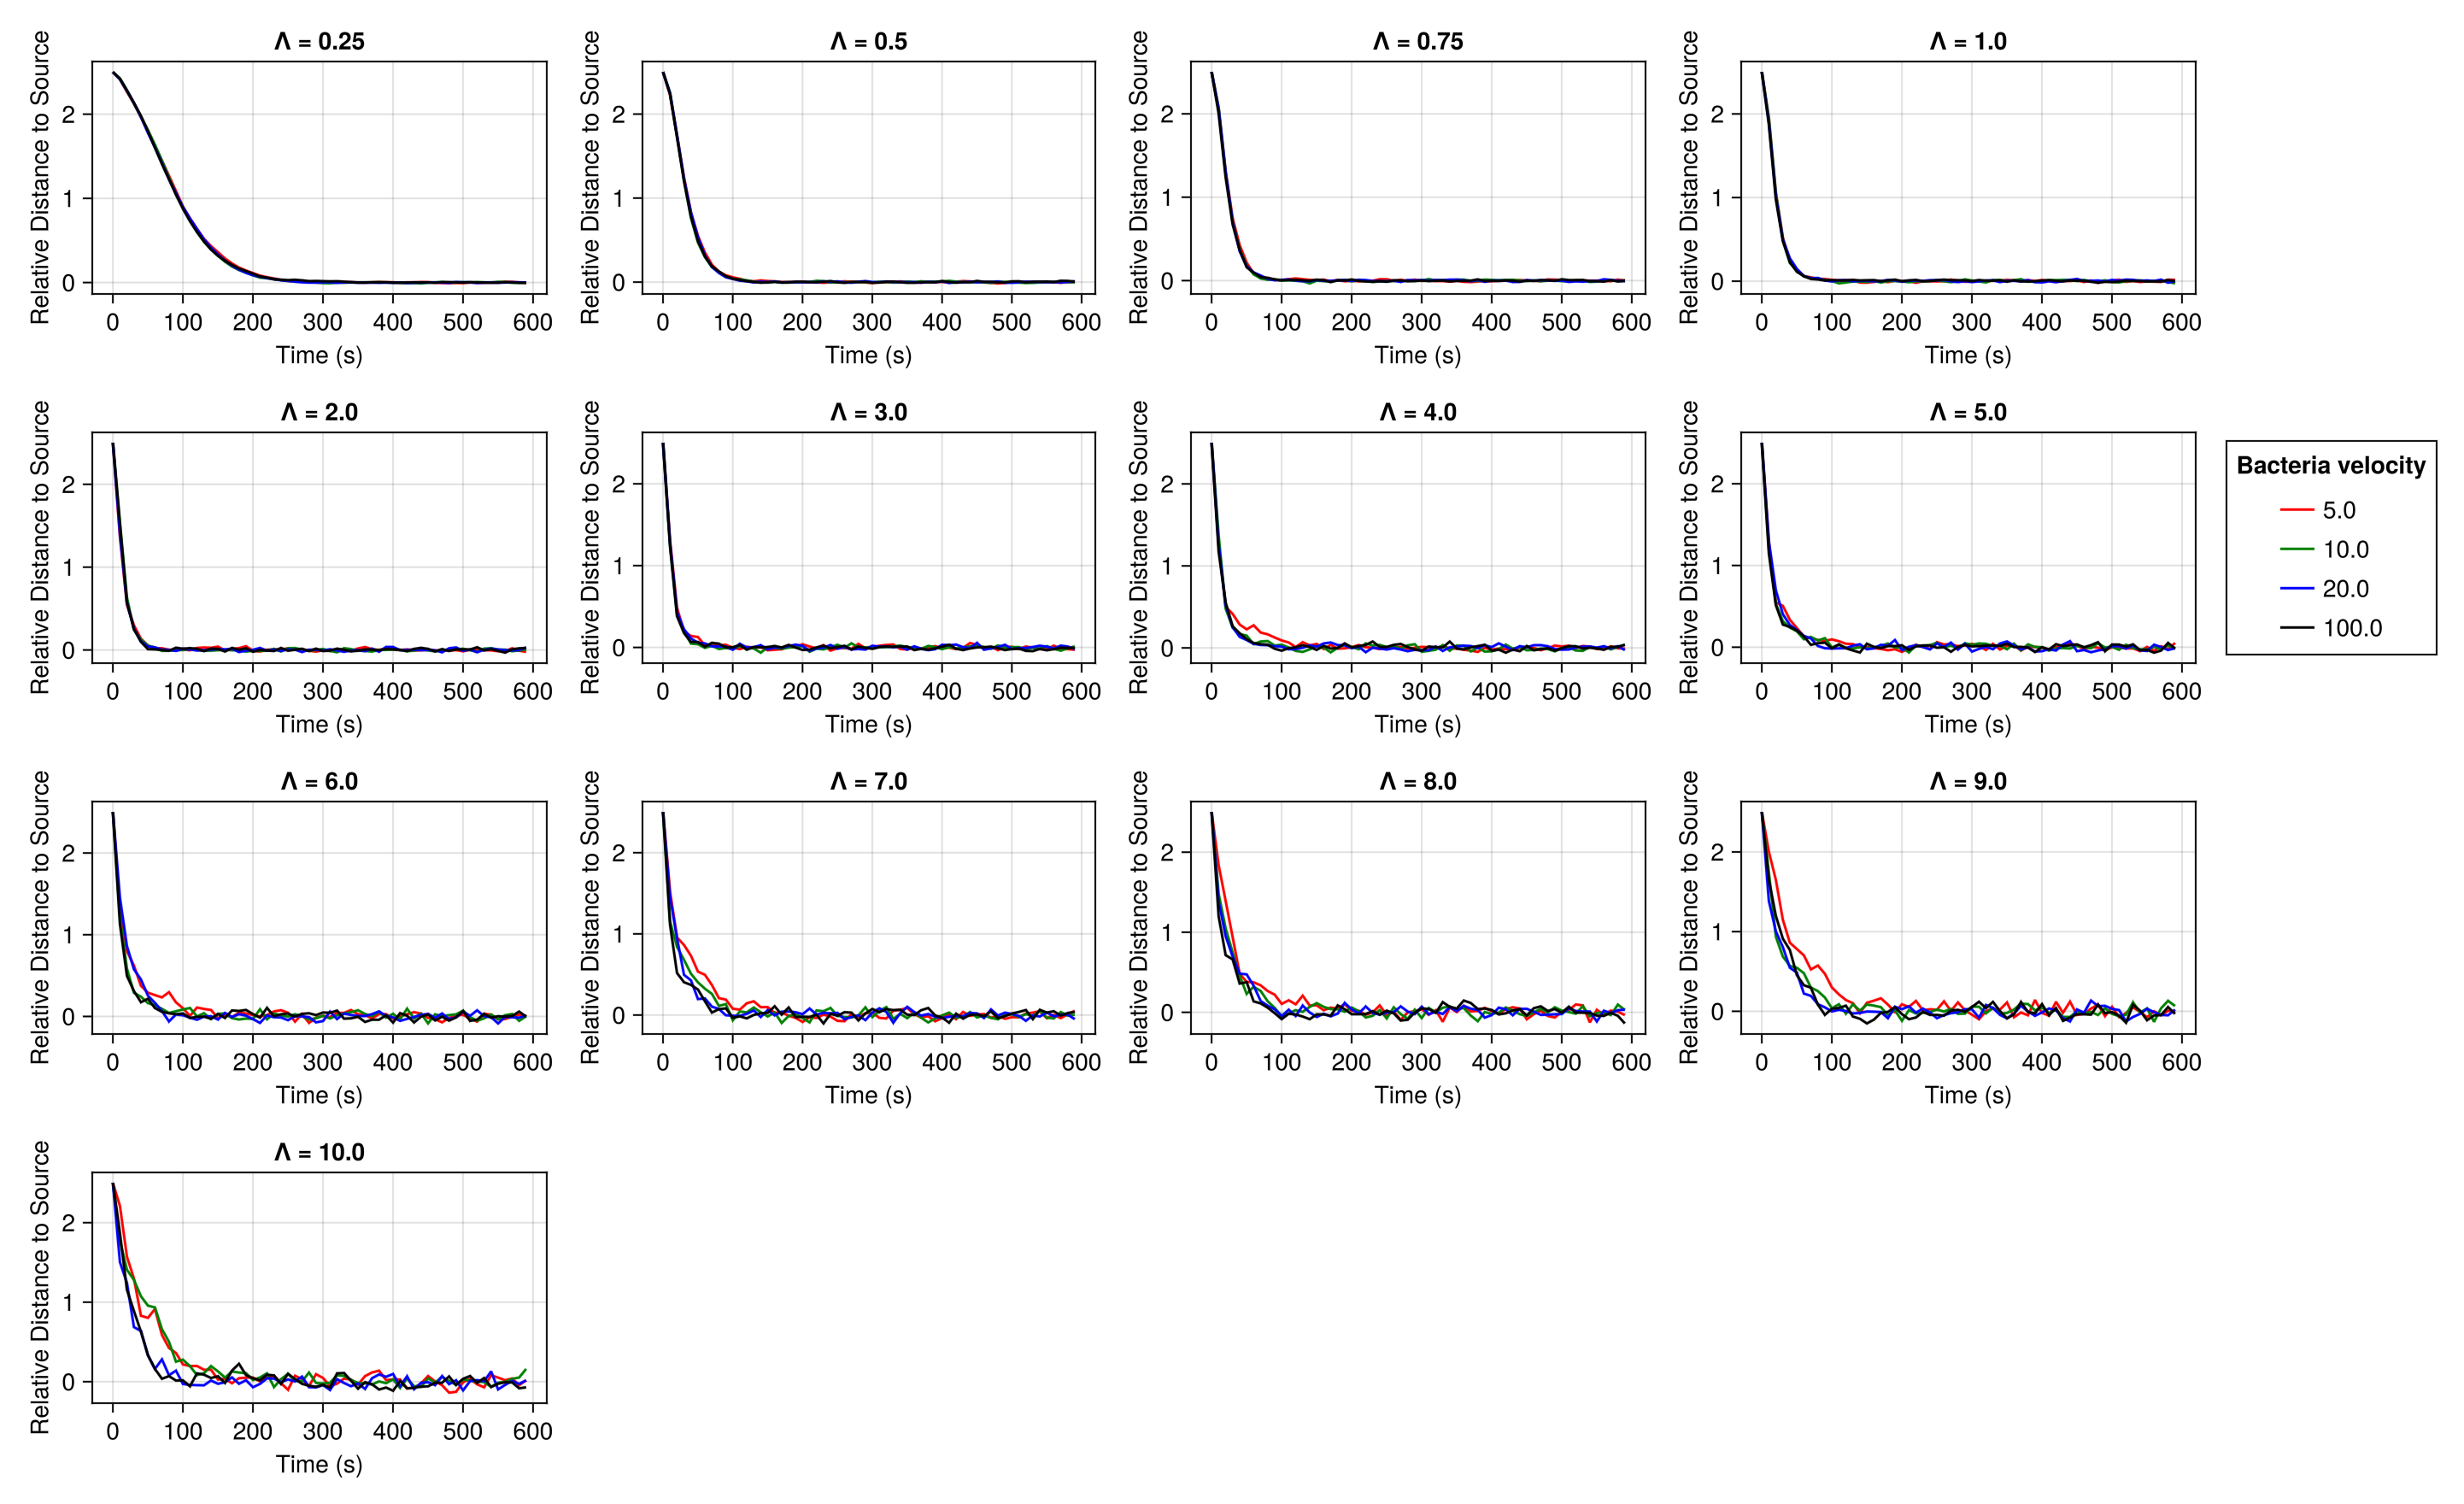

GLMakie.Screen(...)

In [59]:
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000

velocities = [5.0, 10.0, 20.0, 100.0]


colors = [:red, :green, :blue, :black]

# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig2 = Figure(size=(900 * cols, 600 * rows))


for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig2[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source", # Changed label to reflect normalization
              title="Λ = $lambda")

    for (v_idx, v) in enumerate(velocities)

        df = dfs_redo[(v, lambda)]

        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.v .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        for i in 1:100:length(grouped)
            data_1 = grouped[i]
            x = data_1.x ./l
            y = data_1.y ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(x))
        end

        lines!(ax_x, (1:100:length(grouped))*0.1, mean_x, color = color, label = "$v")

        if idx == 13 & v_idx == 4
            fig2[2,5] = Legend(fig2, ax_x, "Bacteria velocity")
        end
    end
end

display(fig2)

In [60]:
save("Plots/Fixed_source_model/Redo/ABM_trapped_x.png", fig2)

# Escape


In [63]:
velocities = [5.0, 10.0, 20.0, 100.0]
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
valid_vec = Int[]
vel_vec = Float64[]
lambda_vec = Float64[]
for (idx, v) in enumerate(velocities) 
    for (l_idx, l) in enumerate(lambdas)
        df = dfs_redo[(v, l)]
        grouped = groupby(df, :step)
        step1 = grouped[1]
        valid = length(step1.agent)
        push!(valid_vec, valid)
        push!(lambda_vec, l)
        push!(vel_vec, v)
    end
end

In [65]:
df_valid_agents = DataFrame(
    v = vel_vec,
    lambda = lambda_vec,
    valid = valid_vec
)

Row,v,lambda,valid
,Float64,Float64,Int64
1,5.0,0.25,996
2,5.0,0.5,1000
3,5.0,0.75,999
4,5.0,1.0,998
5,5.0,2.0,994
6,5.0,3.0,982
7,5.0,4.0,948
8,5.0,5.0,917
9,5.0,6.0,876


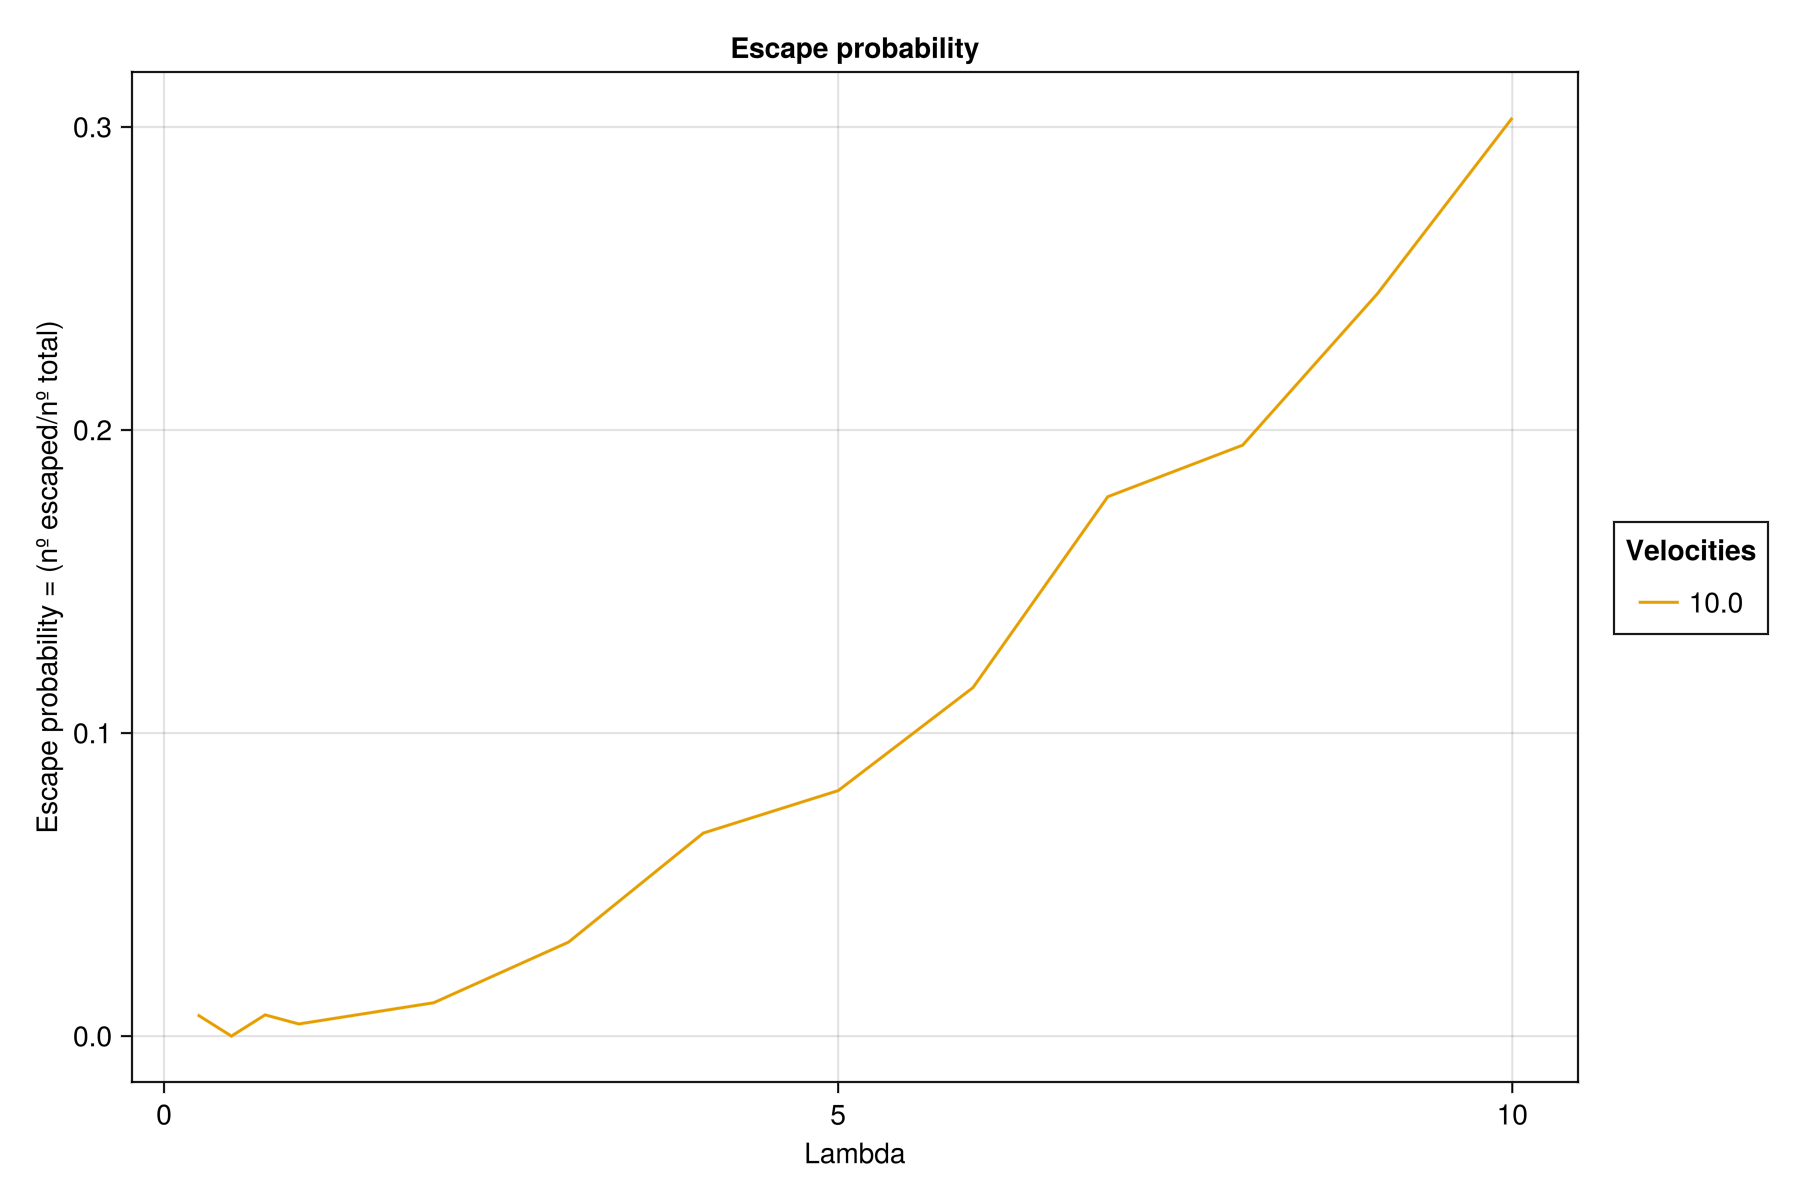

In [71]:
fig4 = Figure(size=(900,600))
ax = Axis(fig4[1,1], xlabel = "Lambda", ylabel = "Escape probability = (nº escaped/nº total)", title = "Escape probability")

colors = [
    # RGBf(0.0, 0.45, 0.70),   # blue
    RGBf(0.90, 0.62, 0.0),   # orange
    # RGBf(0.0, 0.62, 0.45),   # green
    # RGBf(0.80, 0.47, 0.65)   # magenta
]
escape = Float64[]
# velocities = [5.0, 10.0, 20.0, 100.0]
velocities = [10.0]
for (idx,v) in enumerate(velocities)
    color = colors[idx]
    mask = (df_valid_agents.v .== v)
    agents = df_valid_agents.valid[mask]
    lambdas = df_valid_agents.lambda[mask]
    P = 1 .- (agents/1000) 
    escape = P
    lines!(ax, lambdas, P, label = "$v", color = color)
end

fig4[1,2] = Legend(fig4, ax, "Velocities")
fig4

In [72]:
save("Plots/Fixed_source_model/Redo/escape_10.png", fig4)

In [113]:
@save "escape_10_new.jld2" escape